## Feature Selection

In [ ]:
>> Feature Selection is a way of selecting a subset of most relevant features from original dataset
>> Also we try to remove less relevant features, noisy features, redundand features.

Best set of Features 

### Need Feature Selection

In [ ]:
1. Noisy Features
2. Less Important Features
3. Best set of Features

### Benefits of Feature Selection

In [ ]:
1. It takes less computational time (It reduced training and testing time)
2. It improves model efficiecy/results
3. It helps to reduce overfitting
4. It helps to avoid curse of dimensionality

## Features Selection Techniques

In [ ]:
1. Filter Method : (Before Training)
    1. Correlation:
        1. Pearson Correlation Coefficient (Cont vs Cont)
        2. Spearmans Rank Correlation Coefficient(Cont vs Cont)
        3. Kendall Tau Correlation Coefficient(Cont vs Cat)
        
    2. Mutual Infomation(Information Gain)
    3. Fishers Score(Cat)
    4. Chi-Square Test (Cat vs Cat)
    5. Anova (Cont vs Cat)
    6. Cramers Rule
    7. Missing Value Ratio
    8. Variance Threshold Method
    9. Mean Absolute Difference
    10. Variance Inflation Factor(VIF)
    
2. Wrapper Method: (With Training)
    * It uses Machine Learning Algorithm to find best subset of features from dataset
    1. Forward Feature Selection
    2. Backward Feature Elimination
    3. Recursive Feature Elimination
    4. Bi-Directional Feature Selection
    5. Exhaustive Feature Elimination
    6. Boruta Py
    
3. Embedded Method: (Post Training)
    1. Regularization:
        1. Lasso Regression (L1 Regularization)
    2. Decision Tree Feature Importance
    3. Random Forest Feature Importance
    4. AdaBoost Feature Importance
    5. LighGBM Feature Importance
    6. XGBoost Feature Importance
    7. CatBoost Feature Importance

### Feature Extraction

In [ ]:
1. Principal Component Analysis (PCA)
2. Linear Discriminant Analysis(LDA)

## Model Interpretation

In [ ]:
Types of Models:
    1. White-Box Models:
        1. Linear Regression
        2. Logistic Regression
        3. Regularization(L1,L2)
        
    2. Black-Box Models(Usually Tree Based Models)

1. Shapley Values/Plot
2. LIME
3. ELI5

# Filter Method

## Correlation

### Spearman Rank Correlation Coefficient

In [ ]:
Ranges from 0 to 1
It works well when we have linear or non-linear relationship

### Kendall (Tau) Correlation Coefficient

In [ ]:
- It is a non-parametric test that is used to measure degree of association between 2 varibles
- It is best suited for discrete(categorical)

Kendall is preffered than spearmans because of more robustness

In [ ]:
Pearson: Variables should be contineous
         should be normally distributed
         relation should be linear
         outliers need to be handle

Spearmans: Variables should be contineous
           Works well on ordinal data
           Works well on monotonic data
           determins strength and direction of monotonic relation
           little bit of outliers can be overviewed

Kendall:   When data doesnt meat pearsons/spearmans requirements
           Its non-parametric, so no need of normal distribution
           does not require contineous data
           suited for categorical data

## Filter Method

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

In [2]:
boston_df = pd.read_csv('BostonHousing.csv')
boston_df = boston_df.rename({'medv':'target'}, axis =1)
boston_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,target
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
data_wine = load_wine()
wine_df = pd.DataFrame(data_wine.data, columns=data_wine.feature_names)
wine_df['target'] = data_wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 1.1 Correlation

#### 1.1.1 Pearson Correlation

In [ ]:
R-value >> -1 to 1

R > 0.7
R < -0.7

<Axes: >

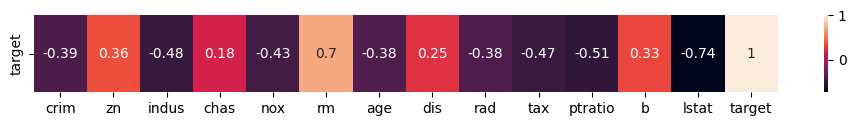

In [18]:
corr = boston_df.corr(method = 'pearson').tail(1)
plt.figure(figsize=(12, 1))
sns.heatmap(corr, annot=True)
# * pearson : standard correlation coefficient
# * kendall : Kendall Tau correlation coefficient
# * spearman : Spearman rank correlation

#### 1.1.2 Spearmans Rank Correlation

<Axes: >

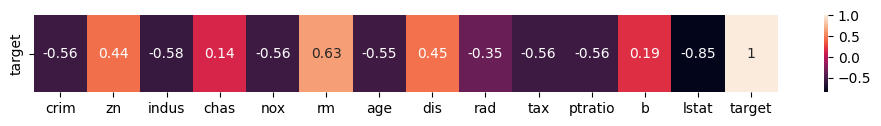

In [19]:
corr = boston_df.corr(method = 'spearman').tail(1)
plt.figure(figsize=(12, 1))
sns.heatmap(corr, annot=True)

#### 1.1.3 Kedall Corrrelation

In [ ]:
Cat vs Cat
Cat vs Cont

<Axes: >

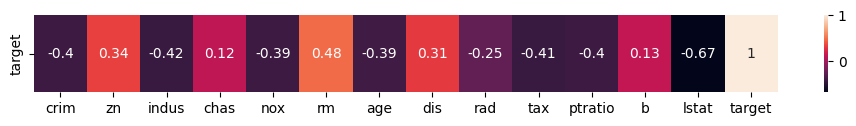

In [4]:
corr = boston_df.corr(method = 'kendall').tail(1)
plt.figure(figsize=(12, 1))
sns.heatmap(corr, annot=True)

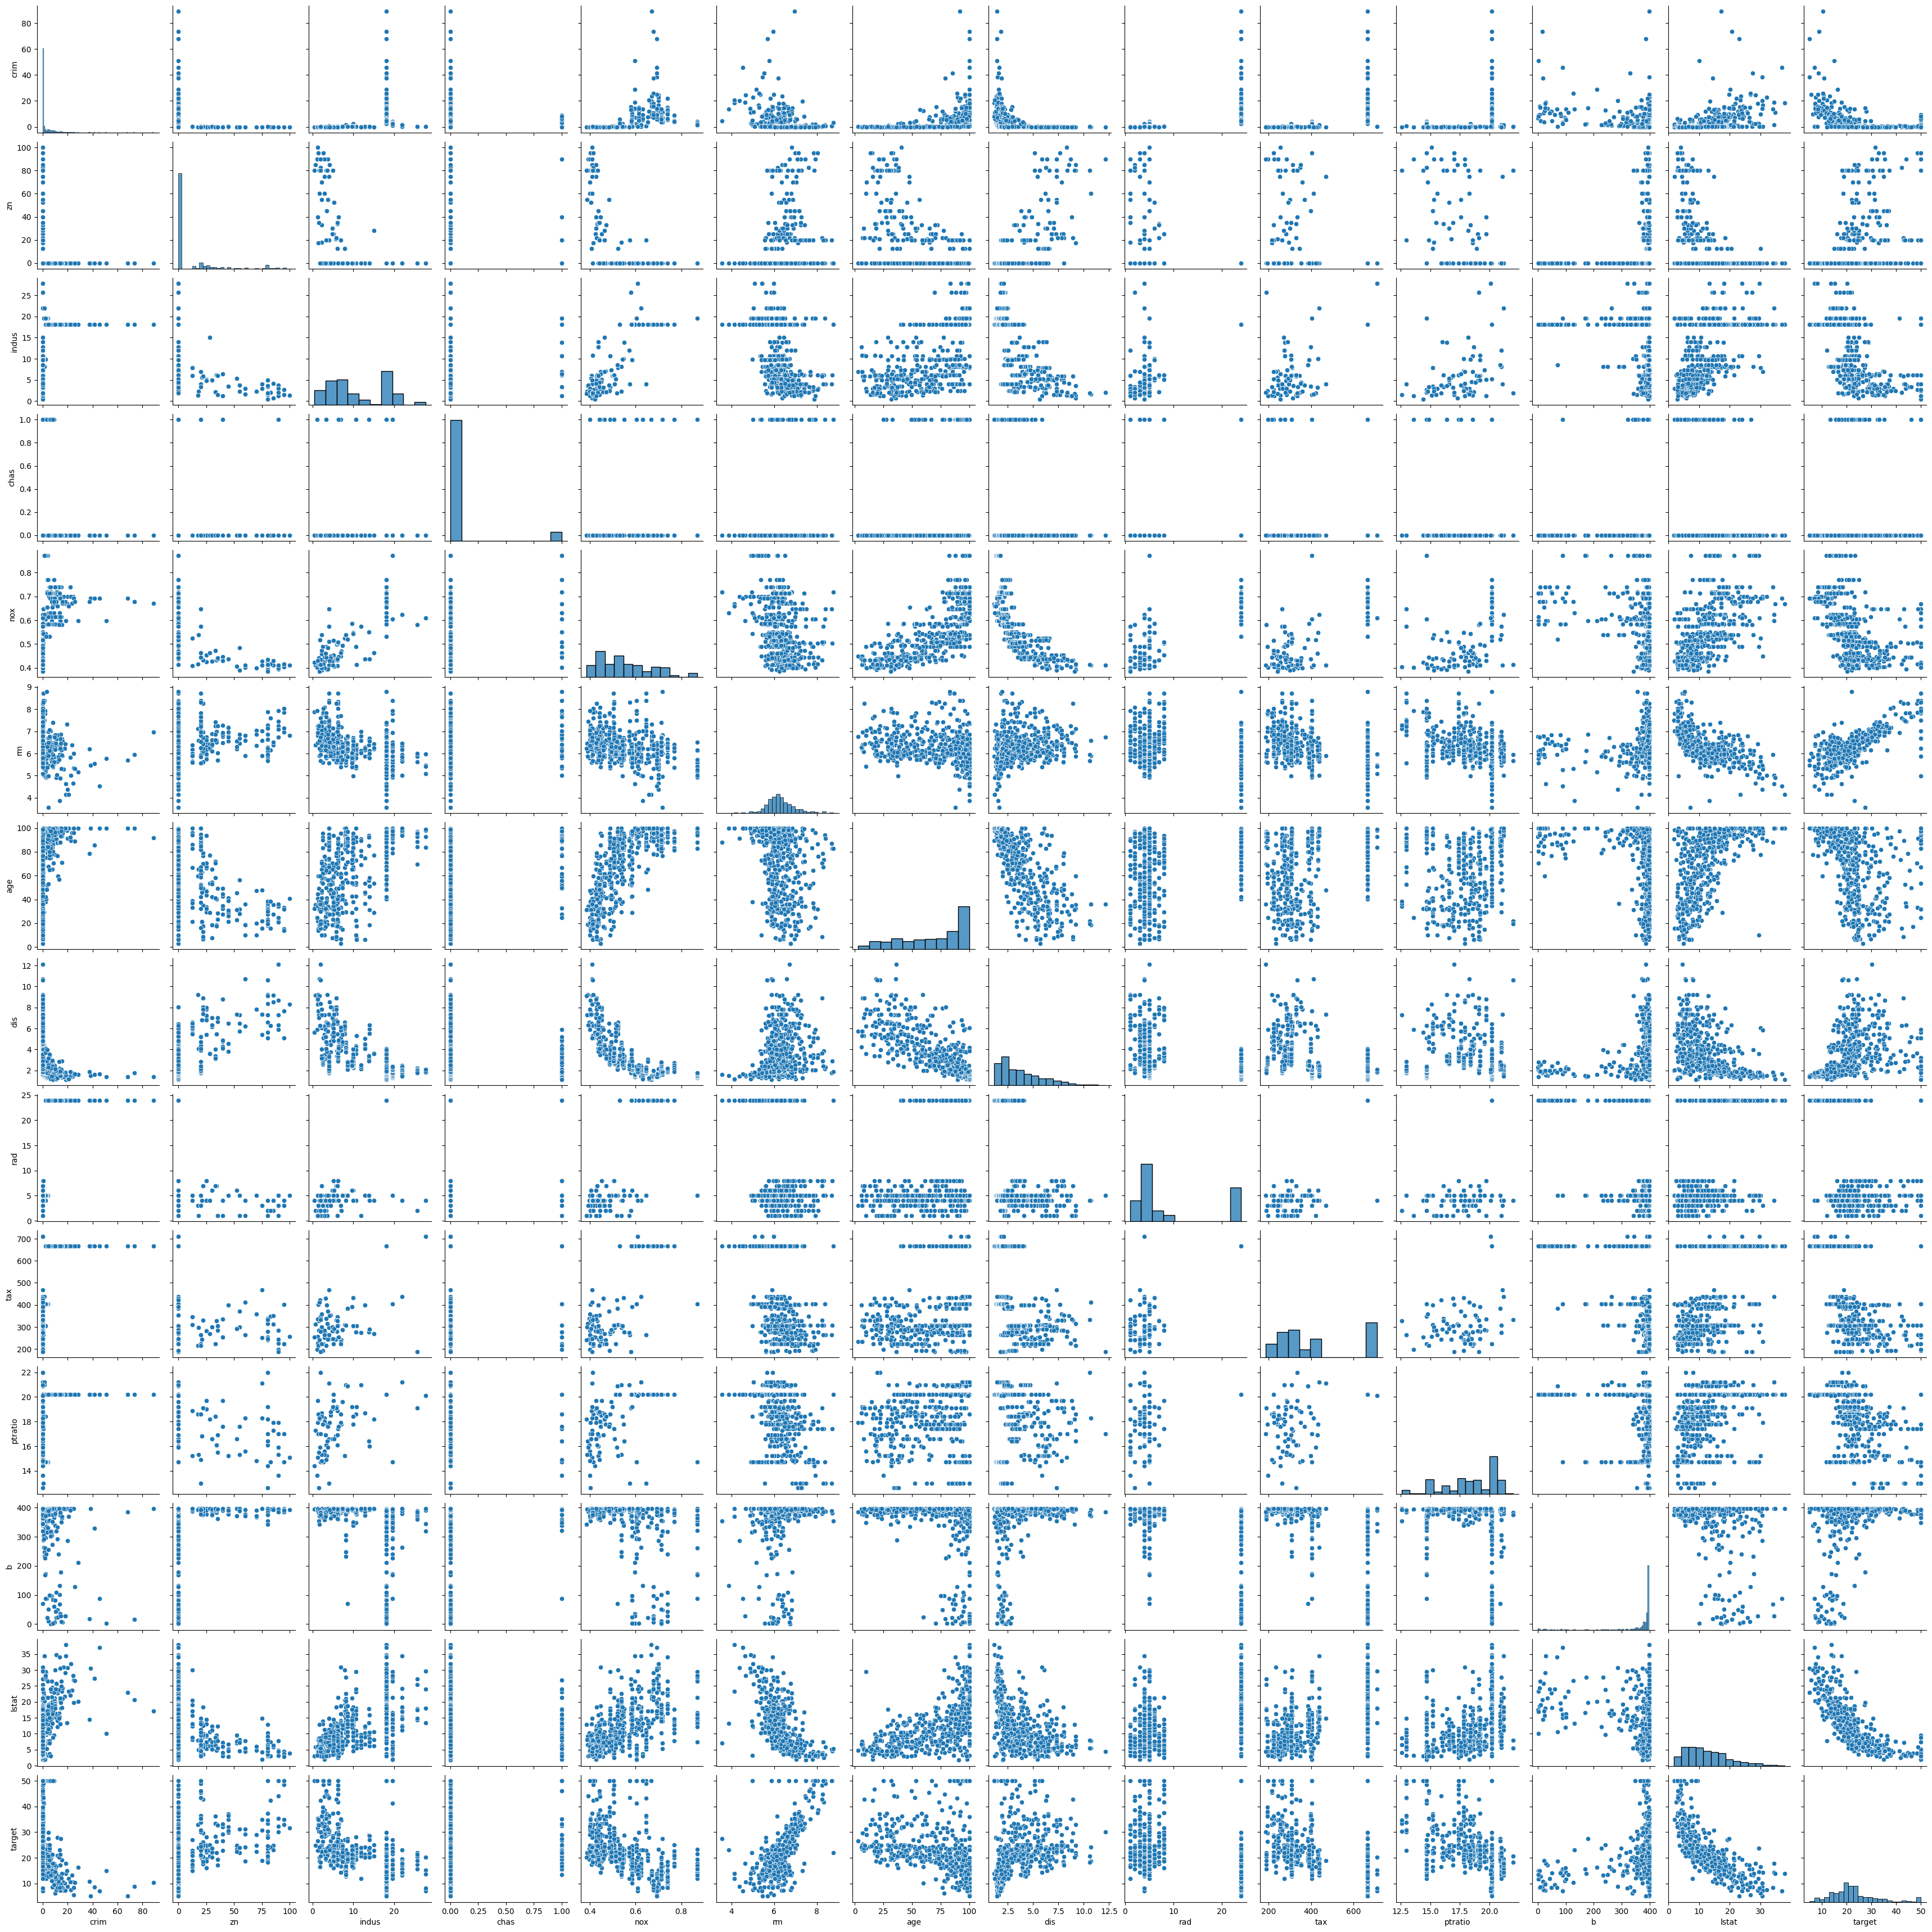

In [22]:
sns.pairplot(boston_df)

### 1.2 Mutual Information(Information Gain)

In [ ]:
- It ranges from 0 to 1
- It is a measure of dependence of mutual dependence between two variables

In [4]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

<Axes: >

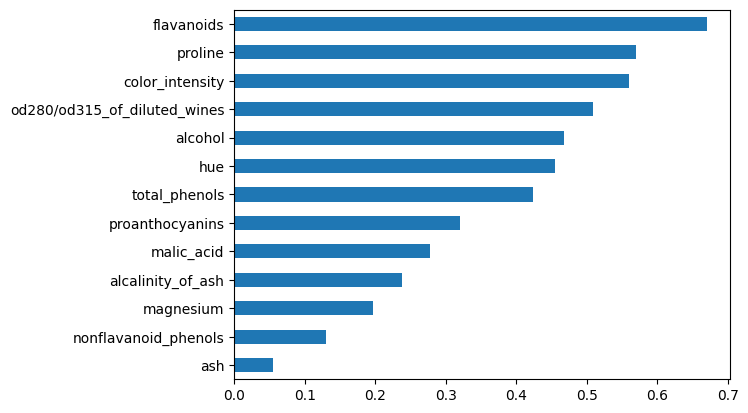

In [6]:
x_wine = wine_df.drop('target', axis = 1)
y_wine = wine_df['target']

arr1 = mutual_info_classif(x_wine, y_wine)
s1 = pd.Series(arr1, index=x_wine.columns)
s1.sort_values().plot(kind='barh')

<Axes: >

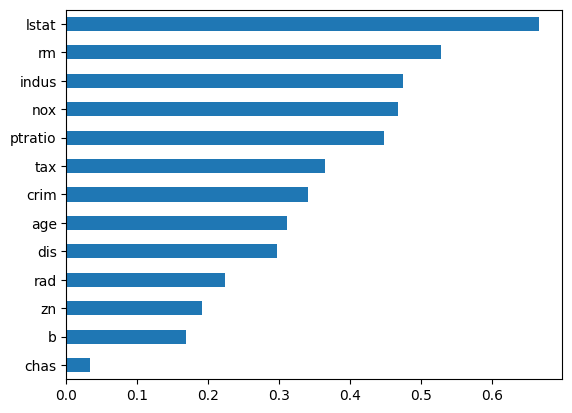

In [7]:
x_boston = boston_df.drop('target', axis = 1)
y_boston = boston_df['target']

arr2 = mutual_info_regression(x_boston, y_boston)
s2 = pd.Series(arr2, index=x_boston.columns)
s2.sort_values().plot(kind='barh')


### 1.3 Fishers Score

In [ ]:
It returns a rank of variables in descending order on fishers score
It works welll on categorical data
Mainly preffered for classification(binary classification)
It will be more accurate on small samples

In [10]:
# pip install skfeature-chappers

In [29]:
# pip install skfeature
# pip install skfeature-chappers

In [11]:
from skfeature.function.similarity_based import fisher_score

<Axes: >

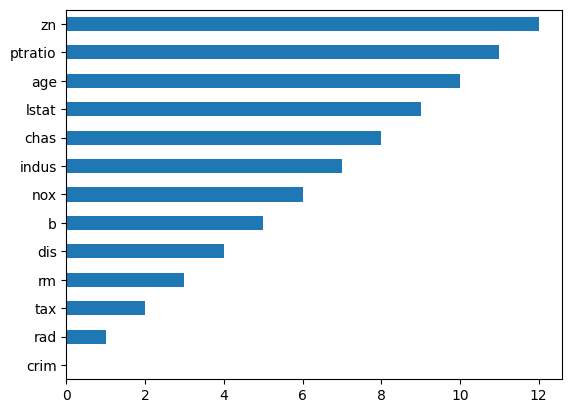

In [12]:
arr3 = fisher_score.fisher_score(x_boston.values, y_boston.values)
s3 = pd.Series(arr3, index=x_boston.columns)
s3.sort_values().plot(kind='barh')

<Axes: >

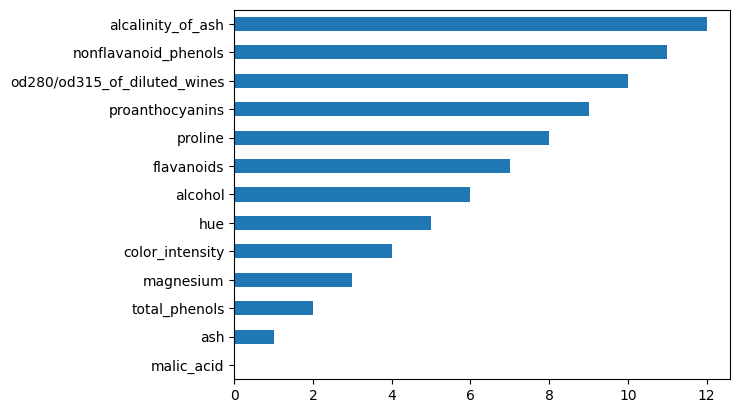

In [13]:
arr4 = fisher_score.fisher_score(x_wine.values, y_wine.values)
s4 = pd.Series(arr4, index=x_wine.columns)
s4.sort_values().plot(kind='barh')

### 1.4 Missing Value Ratios

In [ ]:
Data << 25-30% >> missing values are acceptable

In [14]:
titanic_df = pd.read_csv('titanic.csv')
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
titanic_df.isna().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Gender          0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [16]:
a = ((titanic_df.isna().sum())/len(titanic_df))*100
a

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Gender          0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [17]:
features = titanic_df.columns
features

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [49]:
for i in range(len(features)):
    #print(a[i])
    if a[i] <= 20:
        print(features[i])

PassengerId
Survived
Pclass
Name
Gender
Age
SibSp
Parch
Ticket
Fare
Embarked


In [18]:
selected_features = []
for i in range(len(features)):
    #print(a[i])
    if a[i] <= 20:
        #print(features[i])
        selected_features.append(features[i])

print(selected_features)

['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [19]:
titanic_df[selected_features]

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


### 1.5 Variance Threshold Method

In [ ]:
Works only for numerical features
Looks for variability in the features

Assumptions:
    - Higher variance may contain more useful information
    - remove numerical features with low variance

In [20]:
a = np.array([100,100,100,100])        # Constant Values
np.var(a)

0.0

In [21]:
a = np.array([100,100,100,101])        # Quasi-Constant Values
np.var(a)

0.1875

In [54]:
a = np.array([50,100,150,101])       
np.var(a)

1250.1875

In [22]:
df = wine_df.copy()
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [23]:
df.var()

alcohol                             0.659062
malic_acid                          1.248015
ash                                 0.075265
alcalinity_of_ash                  11.152686
magnesium                         203.989335
total_phenols                       0.391690
flavanoids                          0.997719
nonflavanoid_phenols                0.015489
proanthocyanins                     0.327595
color_intensity                     5.374449
hue                                 0.052245
od280/od315_of_diluted_wines        0.504086
proline                         99166.717355
target                              0.600679
dtype: float64

In [24]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [25]:
df['Test'] = 111
df['Test1'] = 1

In [26]:
df.var()

alcohol                             0.659062
malic_acid                          1.248015
ash                                 0.075265
alcalinity_of_ash                  11.152686
magnesium                         203.989335
total_phenols                       0.391690
flavanoids                          0.997719
nonflavanoid_phenols                0.015489
proanthocyanins                     0.327595
color_intensity                     5.374449
hue                                 0.052245
od280/od315_of_diluted_wines        0.504086
proline                         99166.717355
target                              0.600679
Test                                0.000000
Test1                               0.000000
dtype: float64

In [28]:
from sklearn.feature_selection import VarianceThreshold

var_thresh = VarianceThreshold(threshold=0.50)
var_thresh.fit(df)
var_thresh.get_support()

array([ True,  True, False,  True,  True, False,  True, False, False,
        True, False,  True,  True,  True, False, False])

In [29]:
df.columns[var_thresh.get_support()]

Index(['alcohol', 'malic_acid', 'alcalinity_of_ash', 'magnesium', 'flavanoids',
       'color_intensity', 'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

<Axes: xlabel='ash', ylabel='Density'>

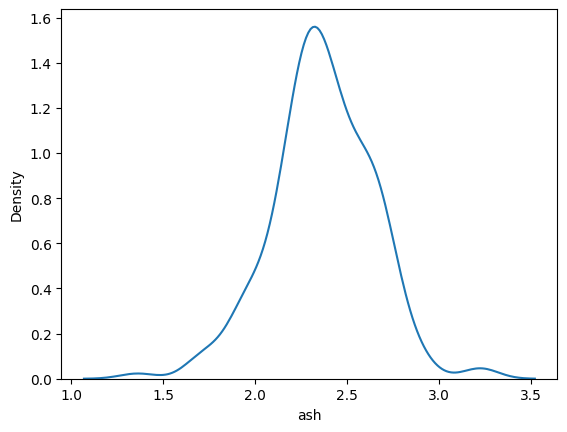

In [30]:
sns.kdeplot(df['ash'])

<Axes: xlabel='ash', ylabel='Density'>

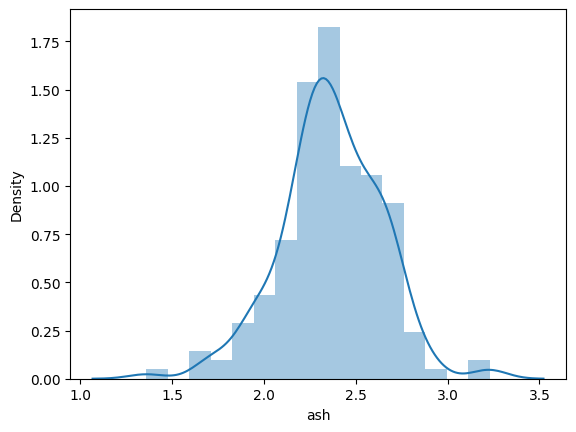

In [31]:
sns.distplot(df['ash'])

<Axes: xlabel='nonflavanoid_phenols', ylabel='Density'>

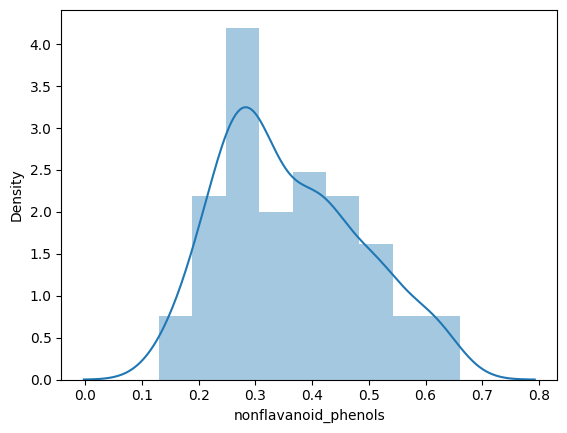

In [32]:
sns.distplot(df['nonflavanoid_phenols'])

### 1.6 Variance Inflation Factor

In [ ]:
VIF >> Mutlicolinearity
VIF >> will be onlu used for independent features
VIF >> 1 to inf
VIF > 10 >> Mutlicolinearity is present 

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

<Axes: >

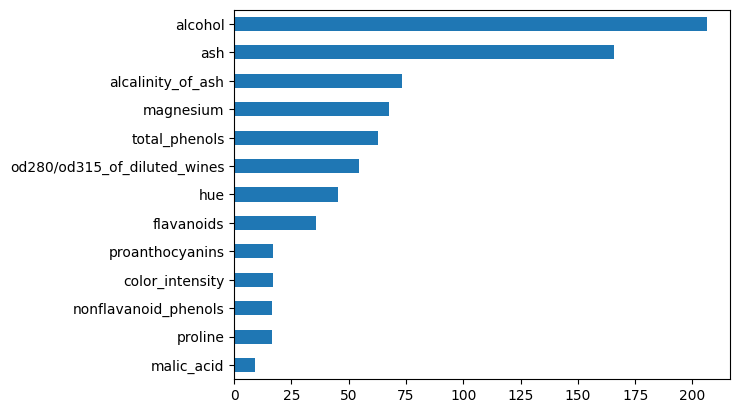

In [34]:
vif_list = []

for i in range(x_wine.shape[1]):
    vif = variance_inflation_factor(x_wine.values, i)
    vif_list.append(vif)

s5 = pd.Series(vif_list, index=x_wine.columns)
s5.sort_values().plot(kind='barh')

In [35]:
wine_df.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


### 1.7 Chi-Square Test

In [ ]:
Chi-Square Test >> To check the relationship between categorical features
It works only on categorical features
Suited for nominal data, ordinal data, dichotomous data
cat vs cat

1. Chi2 Goodness of fit >> Determines if samples data matches the population
2. Chi2 Independence Test

Chi2 is high:
    1. Feature is important
    2. p_val is low (< 0.05)

Chi2 is low:
    1. Feature is not important
    2. p_val is high (> 0.05)

In [ ]:
Null Hypothesis (H0) >> Two variables are independent
Alternate Hypothesis (Ha/H1) >> Two variables are dependent

p_val >= 0.05 >>> H0 is True >> Feature is not important
p_val < 0.05  >>> Ha is True >> Feature is important

Gender  Loan
M        Y
F        N

In [ ]:
Shapiro:
    H0 >> Data is normally distributed
    Ha >> Data is not normally distributed

In [36]:
df = titanic_df[['Survived','Pclass','Gender','SibSp','Parch','Embarked']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Gender    891 non-null    object
 3   SibSp     891 non-null    int64 
 4   Parch     891 non-null    int64 
 5   Embarked  889 non-null    object
dtypes: int64(4), object(2)
memory usage: 41.9+ KB


In [37]:
df['Gender'].replace({'male':1, 'female':0},inplace=True)
df['Embarked'].fillna('S',inplace=True)
df['Embarked'].replace({'Q':0,'C':1, 'S':2},inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Survived  891 non-null    int64
 1   Pclass    891 non-null    int64
 2   Gender    891 non-null    int64
 3   SibSp     891 non-null    int64
 4   Parch     891 non-null    int64
 5   Embarked  891 non-null    int64
dtypes: int64(6)
memory usage: 41.9 KB


In [38]:
x2 = df.drop('Survived',axis=1)
y2 = df['Survived']

In [39]:
from sklearn.feature_selection import chi2, SelectKBest, f_classif, f_oneway, f_regression

In [40]:
chi2_val, p_val = chi2(x2, y2)
chi2_df = pd.DataFrame({'Chi2-Value':chi2_val, 'P-Value':np.around(p_val,3)}, index=x2.columns)
chi2_df.sort_values('P-Value')

,Chi2-Value,P-Value
Pclass,30.115212,0.000
Gender,91.344776,0.000
Parch,10.243662,0.001
Embarked,2.720214,0.099
SibSp,1.752958,0.186


In [15]:
chi2_df[chi2_df['P-Value']< 0.05]

,Chi2-Value,P-Value
Pclass,30.115212,0.000
Gender,91.344776,0.000
Parch,10.243662,0.001


In [16]:
chi2_df[chi2_df['P-Value']< 0.05].index

Index(['Pclass', 'Gender', 'Parch'], dtype='object')

In [18]:
best_feat = SelectKBest(chi2, k=3)
best_feat.fit(x2,y2)
best_feat.scores_
best_feat.pvalues_

array([4.07125230e-08, 1.20698302e-21, 1.85505268e-01, 1.37155024e-03,
       9.90847266e-02])

In [19]:
best_feat.get_support()

array([ True,  True, False,  True, False])

### 1.8 ANOVA Test

In [ ]:
ANOVA >> Analysis of Variance

ANOVA >> To check relationship between cont and cat  variables

f_classif >> Feature Selection >> ind= cont & dep = cat
f_regression >> ind = cat & dep = cont
f_oneway >> TO find out relation of numerical features with multi class target

Null Hypothesis (H0) >> Two variables are independent
Alternate Hypothesis (Ha/H1) >> Two variables are dependent

p_val >= 0.05 >>> H0 is True
p_val < 0.05  >>> Ha is True

In [41]:
f_val, p_val = f_classif(x_wine, y_wine)
df_anova = pd.DataFrame({'F-Val':f_val, 'P-Val':np.around(p_val, 3)}, index=x_wine.columns)
df_anova.sort_values('P-Val')

,F-Val,P-Val
alcohol,135.077624,0.0
malic_acid,36.943425,0.0
ash,13.312901,0.0
alcalinity_of_ash,35.771637,0.0
magnesium,12.429584,0.0
total_phenols,93.733010,0.0
flavanoids,233.925873,0.0
nonflavanoid_phenols,27.575417,0.0
proanthocyanins,30.271383,0.0
color_intensity,120.664018,0.0


### 1.9 Mean Absolute Difference (MAD)

In [ ]:
Absolute diff from mean values of indpendent var

<Axes: >

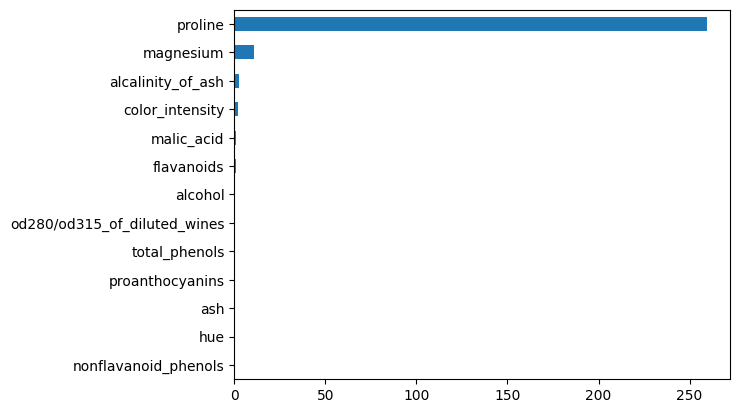

In [42]:
mean_abs_diff = np.sum(np.abs(x_wine - np.mean(x_wine, axis =0)), axis = 0)/x_wine.shape[0]
s6 = pd.Series(mean_abs_diff, index=x_wine.columns)
s6.sort_values().plot(kind='barh')

## 2. Wrapper Method

In [ ]:
Wrapper Method: (With Training) At the time of Model Training
    * It uses Machine Learning Algorithm to find best subset of features from dataset
    1. Forward Feature Selection
    2. Backward Feature Elimination
    3. Recursive Feature Elimination
    4. Bi-Directional Feature Selection
    5. Exhaustive Feature Elimination
    6. Boruta Py

#### 2.1 Forward Feature Selection

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
# knn_model.fit(x_wine, y_wine)

sfs = SequentialFeatureSelector(knn_model, n_features_to_select=5, direction='forward', n_jobs=-1)
sfs.fit(x_wine, y_wine)

SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=5, n_jobs=-1)

In [45]:
arr1 = sfs.get_support()
s1 = pd.Series(arr1, index=x_wine.columns)
s1

alcohol                          True
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                       False
total_phenols                   False
flavanoids                       True
nonflavanoid_phenols             True
proanthocyanins                 False
color_intensity                 False
hue                              True
od280/od315_of_diluted_wines     True
proline                         False
dtype: bool

In [48]:
selected_features = x_wine.columns[arr1]
selected_features

Index(['alcohol', 'flavanoids', 'nonflavanoid_phenols', 'hue',
       'od280/od315_of_diluted_wines'],
      dtype='object')

In [49]:
x_wine[selected_features]

,alcohol,flavanoids,nonflavanoid_phenols,hue,od280/od315_of_diluted_wines
0,14.23,3.06,0.28,1.04,3.92
1,13.20,2.76,0.26,1.05,3.40
2,13.16,3.24,0.30,1.03,3.17
3,14.37,3.49,0.24,0.86,3.45
4,13.24,2.69,0.39,1.04,2.93
...,...,...,...,...,...
173,13.71,0.61,0.52,0.64,1.74
174,13.40,0.75,0.43,0.70,1.56
175,13.27,0.69,0.43,0.59,1.56
176,13.17,0.68,0.53,0.60,1.62


In [25]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
# knn_model.fit(x_wine, y_wine)

for i in range(3, x_wine.shape[1]):
    sfs = SequentialFeatureSelector(knn_model, n_features_to_select=i, direction='forward', n_jobs=-1)
    sfs.fit(x_wine, y_wine)
    selected_features = x_wine.columns[sfs.get_support()]
    knn_model.fit(x_wine[selected_features], y_wine)
    accuracy = knn_model.score(x_wine[selected_features], y_wine)
    print(i, '>>', np.around(accuracy,4))

3 >> 0.9494
4 >> 0.9494
5 >> 0.9607
6 >> 0.9607
7 >> 0.9494
8 >> 0.9551
9 >> 0.9551
10 >> 0.9607
11 >> 0.9607
12 >> 0.927


In [40]:
x_wine.shape

(178, 13)

#### 2.2 Backward Feature Elimination

In [50]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
# knn_model.fit(x_wine, y_wine)

sfs = SequentialFeatureSelector(knn_model, n_features_to_select=5, direction='backward', n_jobs=-1)
sfs.fit(x_wine, y_wine)
s2 = pd.Series(sfs.get_support(), index=x_wine.columns)
s2

alcohol                          True
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                       False
total_phenols                   False
flavanoids                       True
nonflavanoid_phenols            False
proanthocyanins                  True
color_intensity                  True
hue                              True
od280/od315_of_diluted_wines    False
proline                         False
dtype: bool

In [28]:
knn_model = KNeighborsClassifier()
# knn_model.fit(x_wine, y_wine)

for i in range( x_wine.shape[1]-1,4, -1):
    sfs = SequentialFeatureSelector(knn_model, n_features_to_select=i, direction='backward', n_jobs=-1)
    sfs.fit(x_wine, y_wine)
    selected_features = x_wine.columns[sfs.get_support()]
    knn_model.fit(x_wine[selected_features], y_wine)
    accuracy = knn_model.score(x_wine[selected_features], y_wine)
    print(i, '>>', np.around(accuracy,4))

12 >> 0.927
11 >> 0.9607
10 >> 0.9607
9 >> 0.9607
8 >> 0.9719
7 >> 0.9719
6 >> 0.9607
5 >> 0.9607


#### 2.3 Recursive Feature Selection

In [51]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=20)
rfe = RFE(dt_model, n_features_to_select=6)
rfe.fit(x_wine, y_wine)

s3 = pd.Series(rfe.get_support(), index=x_wine.columns)
s3

alcohol                          True
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                        True
total_phenols                   False
flavanoids                       True
nonflavanoid_phenols            False
proanthocyanins                 False
color_intensity                 False
hue                              True
od280/od315_of_diluted_wines     True
proline                          True
dtype: bool

#### 2.4 Exhaustive Feature Selection

In [53]:
# pip install mlxtend

In [32]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector

knn_model = KNeighborsClassifier()
efs = ExhaustiveFeatureSelector(knn_model, min_features=4, max_features=8, cv=3, n_jobs=-1, scoring = 'accuracy')
efs.fit(x_wine, y_wine)
results = pd.DataFrame(efs.subsets_).T
results

Features: 3000/6721IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [33]:
results

,feature_idx,cv_scores,avg_score,feature_names
0,"(0, 1, 2, 3)","[0.7, 0.7966101694915254, 0.7966101694915254]",0.764407,"(alcohol, malic_acid, ash, alcalinity_of_ash)"
1,"(0, 1, 2, 4)","[0.6, 0.7627118644067796, 0.6949152542372882]",0.685876,"(alcohol, malic_acid, ash, magnesium)"
2,"(0, 1, 2, 5)","[0.85, 0.864406779661017, 0.8813559322033898]",0.865254,"(alcohol, malic_acid, ash, total_phenols)"
3,"(0, 1, 2, 6)","[0.85, 0.8983050847457628, 0.9322033898305084]",0.893503,"(alcohol, malic_acid, ash, flavanoids)"
4,"(0, 1, 2, 7)","[0.75, 0.7966101694915254, 0.7966101694915254]",0.781073,"(alcohol, malic_acid, ash, nonflavanoid_phenols)"
...,...,...,...,...
6716,"(4, 5, 6, 7, 9, 10, 11, 12)","[0.6166666666666667, 0.6271186440677966, 0.745...",0.663183,"(magnesium, total_phenols, flavanoids, nonflav..."
6717,"(4, 5, 6, 8, 9, 10, 11, 12)","[0.6166666666666667, 0.6271186440677966, 0.745...",0.663183,"(magnesium, total_phenols, flavanoids, proanth..."
6718,"(4, 5, 7, 8, 9, 10, 11, 12)","[0.6166666666666667, 0.6271186440677966, 0.745...",0.663183,"(magnesium, total_phenols, nonflavanoid_phenol..."
6719,"(4, 6, 7, 8, 9, 10, 11, 12)","[0.6166666666666667, 0.6271186440677966, 0.745...",0.663183,"(magnesium, flavanoids, nonflavanoid_phenols, ..."


In [54]:
results.T

,0,1,2,3,4,5,6,7,8,9,...,6711,6712,6713,6714,6715,6716,6717,6718,6719,6720
feature_idx,"(0, 1, 2, 3)","(0, 1, 2, 4)","(0, 1, 2, 5)","(0, 1, 2, 6)","(0, 1, 2, 7)","(0, 1, 2, 8)","(0, 1, 2, 9)","(0, 1, 2, 10)","(0, 1, 2, 11)","(0, 1, 2, 12)",...,"(3, 6, 7, 8, 9, 10, 11, 12)","(4, 5, 6, 7, 8, 9, 10, 11)","(4, 5, 6, 7, 8, 9, 10, 12)","(4, 5, 6, 7, 8, 9, 11, 12)","(4, 5, 6, 7, 8, 10, 11, 12)","(4, 5, 6, 7, 9, 10, 11, 12)","(4, 5, 6, 8, 9, 10, 11, 12)","(4, 5, 7, 8, 9, 10, 11, 12)","(4, 6, 7, 8, 9, 10, 11, 12)","(5, 6, 7, 8, 9, 10, 11, 12)"
cv_scores,"[0.7, 0.7966101694915254, 0.7966101694915254]","[0.6, 0.7627118644067796, 0.6949152542372882]","[0.85, 0.864406779661017, 0.8813559322033898]","[0.85, 0.8983050847457628, 0.9322033898305084]","[0.75, 0.7966101694915254, 0.7966101694915254]","[0.7833333333333333, 0.7966101694915254, 0.796...","[0.6333333333333333, 0.7796610169491526, 0.864...","[0.7666666666666667, 0.7966101694915254, 0.779...","[0.85, 0.9322033898305084, 0.9491525423728814]","[0.7166666666666667, 0.6101694915254238, 0.711...",...,"[0.7, 0.6271186440677966, 0.7288135593220338]","[0.6333333333333333, 0.847457627118644, 0.8813...","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.6, 0.6271186440677966, 0.7288135593220338]","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.6166666666666667, 0.6271186440677966, 0.745...","[0.7166666666666667, 0.6271186440677966, 0.728..."
avg_score,0.764407,0.685876,0.865254,0.893503,0.781073,0.792185,0.759134,0.780979,0.910452,0.679567,...,0.685311,0.787382,0.663183,0.663183,0.651977,0.663183,0.663183,0.663183,0.663183,0.690866
feature_names,"(alcohol, malic_acid, ash, alcalinity_of_ash)","(alcohol, malic_acid, ash, magnesium)","(alcohol, malic_acid, ash, total_phenols)","(alcohol, malic_acid, ash, flavanoids)","(alcohol, malic_acid, ash, nonflavanoid_phenols)","(alcohol, malic_acid, ash, proanthocyanins)","(alcohol, malic_acid, ash, color_intensity)","(alcohol, malic_acid, ash, hue)","(alcohol, malic_acid, ash, od280/od315_of_dilu...","(alcohol, malic_acid, ash, proline)",...,"(alcalinity_of_ash, flavanoids, nonflavanoid_p...","(magnesium, total_phenols, flavanoids, nonflav...","(magnesium, total_phenols, flavanoids, nonflav...","(magnesium, total_phenols, flavanoids, nonflav...","(magnesium, total_phenols, flavanoids, nonflav...","(magnesium, total_phenols, flavanoids, nonflav...","(magnesium, total_phenols, flavanoids, proanth...","(magnesium, total_phenols, nonflavanoid_phenol...","(magnesium, flavanoids, nonflavanoid_phenols, ...","(total_phenols, flavanoids, nonflavanoid_pheno..."


In [35]:
results.sort_values(by='avg_score', ascending=False)

,feature_idx,cv_scores,avg_score,feature_names
80,"(0, 2, 6, 8)","[0.8666666666666667, 0.9661016949152542, 0.966...",0.932957,"(alcohol, ash, flavanoids, proanthocyanins)"
965,"(0, 2, 6, 7, 8)","[0.8666666666666667, 0.9661016949152542, 0.966...",0.932957,"(alcohol, ash, flavanoids, nonflavanoid_phenol..."
2484,"(0, 2, 5, 6, 10, 11)","[0.8833333333333333, 0.9322033898305084, 0.983...",0.932863,"(alcohol, ash, total_phenols, flavanoids, hue,..."
4383,"(0, 2, 5, 6, 7, 10, 11)","[0.8833333333333333, 0.9322033898305084, 0.983...",0.932863,"(alcohol, ash, total_phenols, flavanoids, nonf..."
1182,"(0, 6, 7, 10, 11)","[0.8333333333333334, 0.9661016949152542, 0.983...",0.927495,"(alcohol, flavanoids, nonflavanoid_phenols, hu..."
...,...,...,...,...
626,"(4, 7, 8, 10)","[0.5, 0.6440677966101694, 0.5932203389830508]",0.579096,"(magnesium, nonflavanoid_phenols, proanthocyan..."
1661,"(2, 4, 7, 8, 10)","[0.5166666666666667, 0.6101694915254238, 0.593...",0.573352,"(ash, magnesium, nonflavanoid_phenols, proanth..."
434,"(2, 4, 7, 8)","[0.5166666666666667, 0.5932203389830508, 0.593...",0.567702,"(ash, magnesium, nonflavanoid_phenols, proanth..."
440,"(2, 4, 8, 10)","[0.4666666666666667, 0.5932203389830508, 0.610...",0.556685,"(ash, magnesium, proanthocyanins, hue)"


In [36]:
efs.best_feature_names_

('alcohol', 'ash', 'flavanoids', 'proanthocyanins')

In [37]:
efs.best_idx_

(0, 2, 6, 8)

In [38]:
efs.best_score_

0.9329566854990584

In [39]:
results[results['avg_score']>0.9].sort_values('avg_score', ascending=False)

,feature_idx,cv_scores,avg_score,feature_names
965,"(0, 2, 6, 7, 8)","[0.8666666666666667, 0.9661016949152542, 0.966...",0.932957,"(alcohol, ash, flavanoids, nonflavanoid_phenol..."
80,"(0, 2, 6, 8)","[0.8666666666666667, 0.9661016949152542, 0.966...",0.932957,"(alcohol, ash, flavanoids, proanthocyanins)"
2484,"(0, 2, 5, 6, 10, 11)","[0.8833333333333333, 0.9322033898305084, 0.983...",0.932863,"(alcohol, ash, total_phenols, flavanoids, hue,..."
4383,"(0, 2, 5, 6, 7, 10, 11)","[0.8833333333333333, 0.9322033898305084, 0.983...",0.932863,"(alcohol, ash, total_phenols, flavanoids, nonf..."
1182,"(0, 6, 7, 10, 11)","[0.8333333333333334, 0.9661016949152542, 0.983...",0.927495,"(alcohol, flavanoids, nonflavanoid_phenols, hu..."
...,...,...,...,...
3861,"(0, 1, 2, 5, 6, 7, 11)","[0.8666666666666667, 0.8813559322033898, 0.966...",0.904708,"(alcohol, malic_acid, ash, total_phenols, flav..."
5653,"(0, 1, 2, 5, 7, 8, 10, 11)","[0.8666666666666667, 0.8983050847457628, 0.949...",0.904708,"(alcohol, malic_acid, ash, total_phenols, nonf..."
2070,"(0, 1, 2, 5, 6, 11)","[0.8666666666666667, 0.8813559322033898, 0.966...",0.904708,"(alcohol, malic_acid, ash, total_phenols, flav..."
842,"(0, 1, 5, 10, 11)","[0.8666666666666667, 0.8983050847457628, 0.949...",0.904708,"(alcohol, malic_acid, total_phenols, hue, od28..."


#### 2.5 Bi-Directional Feature Selection

In [40]:
# from sklearn.feature_selection import SequentialFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

knn_model = KNeighborsClassifier()
sfs = SequentialFeatureSelector(knn_model, k_features=(4,8), forward=True, floating=True, n_jobs=-1, scoring = 'accuracy')
sfs.fit(x_wine, y_wine)
results2 = pd.DataFrame(sfs.subsets_).T
results2

,feature_idx,cv_scores,avg_score,feature_names
1,"(6,)","[0.6944444444444444, 0.8333333333333334, 0.694...",0.75873,"(flavanoids,)"
2,"(0, 6)","[0.7777777777777778, 0.9444444444444444, 0.972...",0.921746,"(alcohol, flavanoids)"
3,"(0, 6, 7)","[0.8611111111111112, 0.9444444444444444, 0.972...",0.938413,"(alcohol, flavanoids, nonflavanoid_phenols)"
4,"(0, 6, 7, 10)","[0.8333333333333334, 0.9444444444444444, 0.972...",0.938571,"(alcohol, flavanoids, nonflavanoid_phenols, hue)"
5,"(0, 6, 7, 10, 11)","[0.7777777777777778, 0.9444444444444444, 1.0, ...",0.93873,"(alcohol, flavanoids, nonflavanoid_phenols, hu..."
6,"(0, 5, 6, 7, 10, 11)","[0.8055555555555556, 0.9166666666666666, 1.0, ...",0.93873,"(alcohol, total_phenols, flavanoids, nonflavan..."
7,"(0, 2, 5, 6, 7, 10, 11)","[0.8333333333333334, 0.9444444444444444, 1.0, ...",0.944127,"(alcohol, ash, total_phenols, flavanoids, nonf..."
8,"(0, 2, 5, 6, 7, 9, 10, 11)","[0.7777777777777778, 0.8888888888888888, 1.0, ...",0.927619,"(alcohol, ash, total_phenols, flavanoids, nonf..."


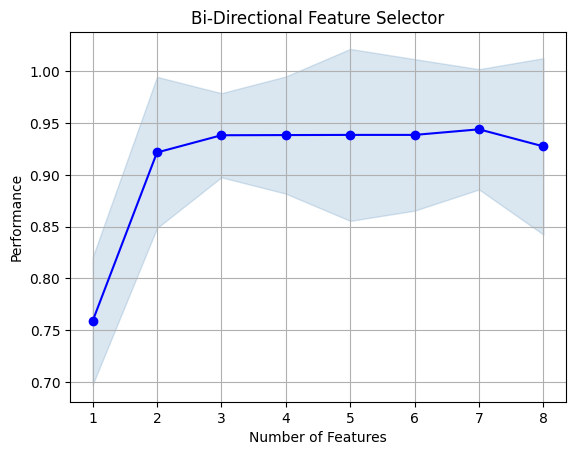

In [41]:
fig = plot_sfs(sfs.get_metric_dict())
plt.title('Bi-Directional Feature Selector')
plt.grid()
plt.show()

In [42]:
# from sklearn.feature_selection import SequentialFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

knn_model = KNeighborsClassifier()
sfs = SequentialFeatureSelector(knn_model, k_features=(4,8), forward=False, floating=True, n_jobs=-1, scoring = 'accuracy')
sfs.fit(x_wine, y_wine)
results3 = pd.DataFrame(sfs.subsets_).T
results3

,feature_idx,cv_scores,avg_score,feature_names
13,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)","[0.7222222222222222, 0.6666666666666666, 0.638...",0.69127,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
12,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.75, 0.7777777777777778, 0.9166666666666666,...",0.820317,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
11,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11)","[0.7777777777777778, 0.9444444444444444, 0.916...",0.927778,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
10,"(0, 1, 2, 3, 6, 7, 8, 9, 10, 11)","[0.8333333333333334, 0.9444444444444444, 0.916...",0.938889,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
9,"(0, 1, 2, 3, 6, 7, 8, 9, 11)","[0.8333333333333334, 0.9444444444444444, 0.916...",0.938889,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
8,"(0, 1, 2, 3, 6, 8, 9, 11)","[0.8333333333333334, 0.9444444444444444, 0.916...",0.938889,"(alcohol, malic_acid, ash, alcalinity_of_ash, ..."
7,"(0, 1, 3, 6, 8, 9, 11)","[0.8055555555555556, 0.9444444444444444, 0.916...",0.933333,"(alcohol, malic_acid, alcalinity_of_ash, flava..."
6,"(0, 1, 3, 6, 8, 9)","[0.8333333333333334, 0.9444444444444444, 0.916...",0.933175,"(alcohol, malic_acid, alcalinity_of_ash, flava..."
5,"(0, 5, 6, 8, 9)","[0.8055555555555556, 0.9166666666666666, 1.0, ...",0.944444,"(alcohol, total_phenols, flavanoids, proanthoc..."
4,"(0, 6, 8, 9)","[0.8055555555555556, 0.8888888888888888, 1.0, ...",0.938889,"(alcohol, flavanoids, proanthocyanins, color_i..."


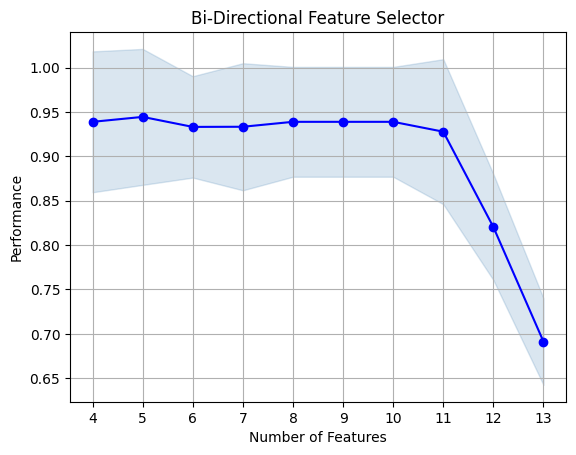

In [43]:
fig = plot_sfs(sfs.get_metric_dict())
plt.title('Bi-Directional Feature Selector')
plt.grid()
plt.show()

In [44]:
sfs.get_metric_dict()

{13: {'feature_idx': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12),
  'cv_scores': array([0.72222222, 0.66666667, 0.63888889, 0.65714286, 0.77142857]),
  'avg_score': 0.6912698412698413,
  'feature_names': ('alcohol',
   'malic_acid',
   'ash',
   'alcalinity_of_ash',
   'magnesium',
   'total_phenols',
   'flavanoids',
   'nonflavanoid_phenols',
   'proanthocyanins',
   'color_intensity',
   'hue',
   'od280/od315_of_diluted_wines',
   'proline'),
  'ci_bound': 0.06269586209180822,
  'std_dev': 0.04877951071049148,
  'std_err': 0.02438975535524574},
 12: {'feature_idx': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),
  'cv_scores': array([0.75      , 0.77777778, 0.91666667, 0.8       , 0.85714286]),
  'avg_score': 0.8203174603174602,
  'feature_names': ('alcohol',
   'malic_acid',
   'ash',
   'alcalinity_of_ash',
   'magnesium',
   'total_phenols',
   'flavanoids',
   'nonflavanoid_phenols',
   'proanthocyanins',
   'color_intensity',
   'hue',
   'od280/od315_of_diluted_wines'),
  'ci_bound': 

In [45]:
results3.to_csv('Bi-Directional Result.csv')

#### 2.6 Boruta Py

In [ ]:
Rank 1: Features with a rank of 1 are considered the most important. 
These are the features that BorutaPy has selected as significant.

Higher Ranks (2, 3, etc.): Features with higher ranks (2, 3, and beyond) are considered less important. 
The higher the rank, the less important the feature is according to BorutaPy.

In [47]:
# pip install Boruta

In [48]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rfm = RandomForestClassifier(random_state=20)

boruta_select = BorutaPy(rfm, n_estimators= 'auto')
boruta_select.fit(x_wine.values, y_wine.values)



BorutaPy(estimator=RandomForestClassifier(n_estimators=50,
                                          random_state=RandomState(MT19937) at 0x14FFE9F3740),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x14FFE9F3740)

In [49]:
boruta_ranking = boruta_select.ranking_
boruta_ranking

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## 3. Embedded Method

#### 3.1 Regularization

In [ ]:
Lasso Regression(L1 Regularization)

y = m1x1 + m2x2 + m3x3 + m4x4 + c

Penalty to slopes
x1 = 15 >> 0.8 
x2 = 20 >> 1.4
x3 = 8  >> 0  (We can drop this feature )
x4 = 13 >> 0.4

features = [x1,x2,x4]

#### 3.2 Tree Based Feature Importance

In [50]:
rf_model = RandomForestClassifier(min_samples_leaf=5, max_depth=4, random_state=20)
rf_model.fit(x_wine, y_wine)
rf_model.feature_importances_

array([0.15139421, 0.03028753, 0.00699551, 0.01898158, 0.02450394,
       0.04790139, 0.13298658, 0.01563366, 0.02298305, 0.17259333,
       0.08276069, 0.12702627, 0.16595227])

In [51]:
sum(rf_model.feature_importances_)

1.0000000000000002

<Axes: >

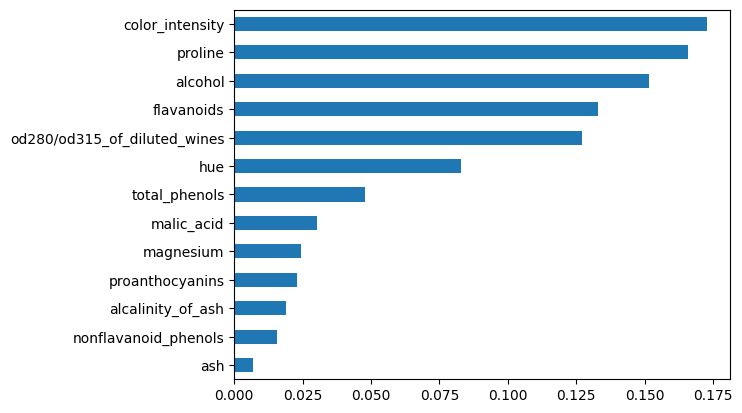

In [52]:
s7 = pd.Series(rf_model.feature_importances_, index = x_wine.columns)
s7.sort_values().plot(kind='barh')

## Model Interpretation through Shapley

In [ ]:
Features Importances and Directionality

In [54]:
# pip install shap

In [55]:
x_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [56]:
import shap

In [57]:
explainer = shap.TreeExplainer(rf_model)

shap_values  = explainer.shap_values(x_wine)
shap_values

array([[[ 1.14811068e-01, -1.20804724e-01,  5.99365627e-03],
        [ 1.54968131e-02, -2.65821113e-03, -1.28386020e-02],
        [ 3.08105592e-03, -3.89187422e-03,  8.10818303e-04],
        ...,
        [ 3.53186539e-02,  1.76647602e-02, -5.29834141e-02],
        [ 7.00858057e-02,  2.14201761e-03, -7.22278233e-02],
        [ 1.61753148e-01, -1.27217304e-01, -3.45358441e-02]],

       [[ 1.01739188e-01, -1.10606874e-01,  8.86768511e-03],
        [ 1.56561617e-02, -1.85535083e-03, -1.38008108e-02],
        [-5.90008198e-03,  7.67148122e-03, -1.77139924e-03],
        ...,
        [ 3.62723301e-02,  1.98469849e-02, -5.61193150e-02],
        [ 6.86535331e-02,  4.22118802e-03, -7.28747212e-02],
        [ 1.62740247e-01, -1.30454403e-01, -3.22858446e-02]],

       [[ 9.06701377e-02, -9.87781644e-02,  8.10802670e-03],
        [-6.30013711e-03, -4.19469815e-03,  1.04948353e-02],
        [ 5.06647503e-03, -8.75283883e-03,  3.68636380e-03],
        ...,
        [ 3.92855090e-02,  1.83724912e-02,

In [58]:
y_wine.unique()

array([0, 1, 2])

In [87]:
shap_values.shape

(178, 13, 3)

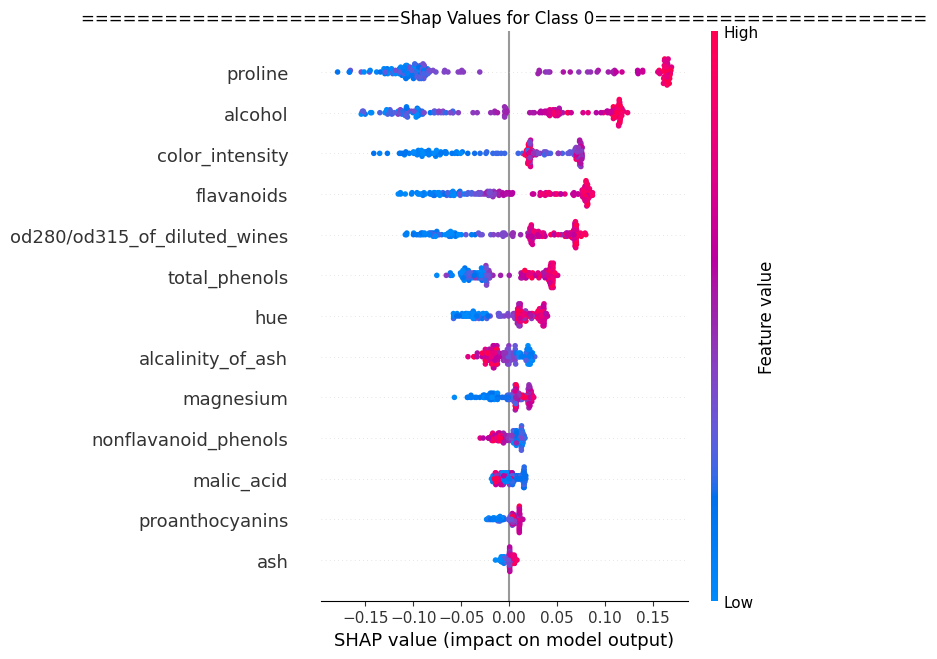

In [59]:
plt.title('Shap Values for Class 0'.center(70, '='))
shap.summary_plot(shap_values[:,:,0], x_wine, plot_type='dot')
plt.show()

In [91]:
x_wine.shape

(178, 13)

In [92]:
shap_values.shape

(178, 13, 3)

In [99]:
shap_values[:,:,0].shape

(178, 13)

In [ ]:
>> Proline is most important feature
>> higher values of proline is expected for class 0
>> lower values of proline is not expected for class 0

In [102]:
x_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


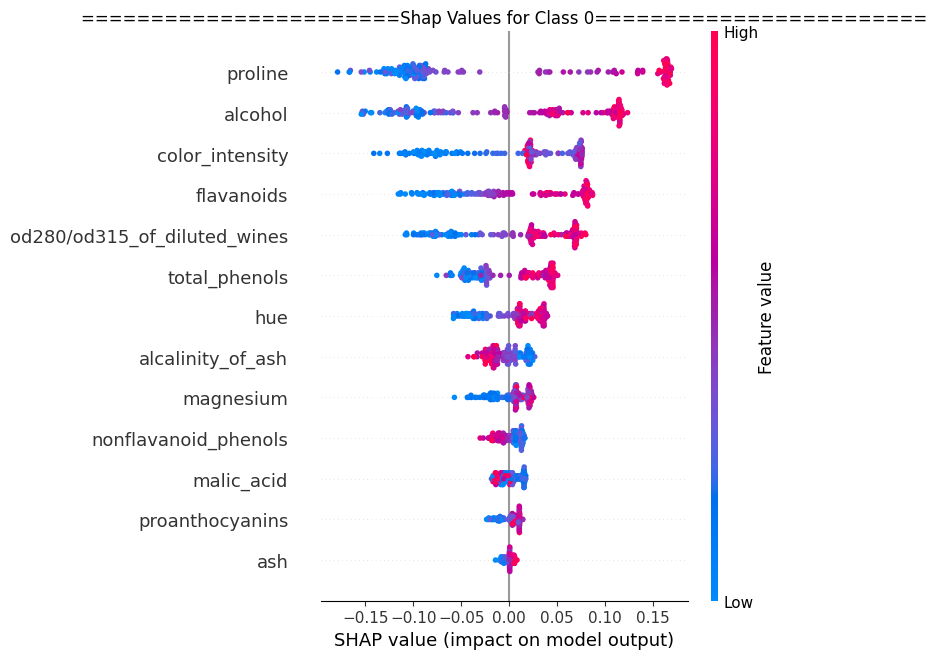

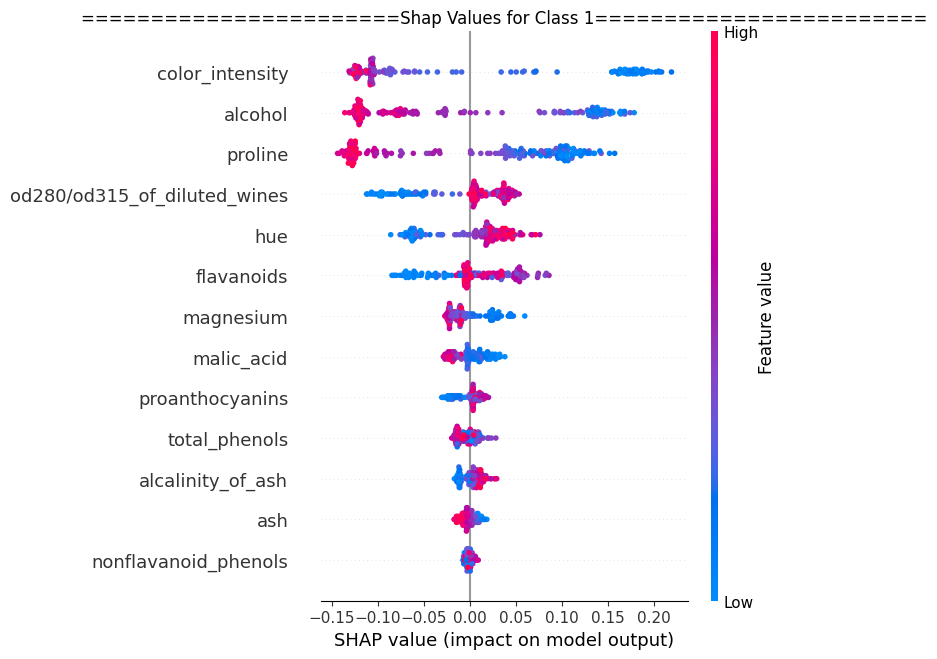

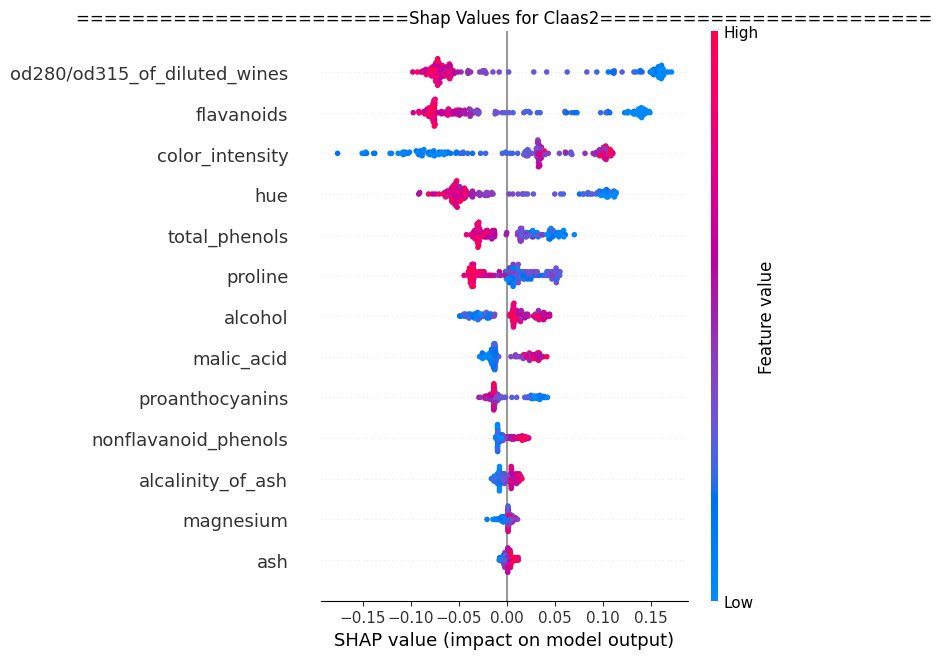

In [60]:
for class_index, class_label in enumerate(['Class 0','Class 1','Claas2']):
    plt.title(f'Shap Values for {class_label}'.center(70, '='))
    shap.summary_plot(shap_values[:,:,class_index], x_wine, plot_type='dot')
    plt.show()
    print('\n')
    plt.close()